# Walkthrough - Classical Forecasting with ARIMA

On the classic Mauna Loa atmospheric CO2 series (weekly, 1958-2001) we will:
1. Decompose the series and reason about stationarity.
2. Read ACF/PACF plots after differencing.
3. Fit a SARIMA model and *check its residuals*.
4. Forecast with honest uncertainty intervals, and backtest against naive baselines.

Companion lesson: Lesson 01 - Classical Time Series Analysis.

1975-01-01 00:00:00 to 2001-12-01 00:00:00 (324 months)


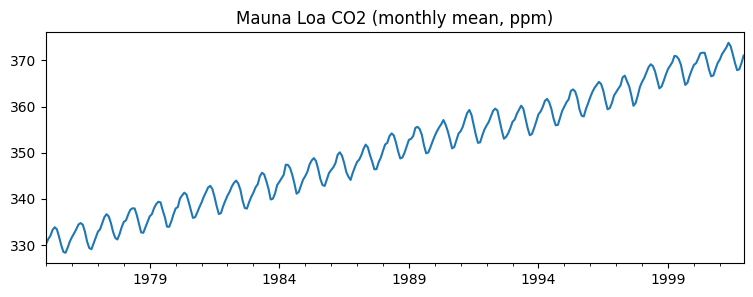

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

co2 = sm.datasets.co2.load_pandas().data["co2"]
y = co2.resample("MS").mean().ffill()  # monthly means, small gaps forward-filled
y = y.loc["1975":]                     # keep it modest for speed
print(y.index.min(), "to", y.index.max(), f"({len(y)} months)")

y.plot(figsize=(9, 3), title="Mauna Loa CO2 (monthly mean, ppm)")
plt.show()

## Part 1 - Decomposition and stationarity

Trend + strong annual seasonality: clearly non-stationary. The classical workflow:
difference until stationary, model what remains.

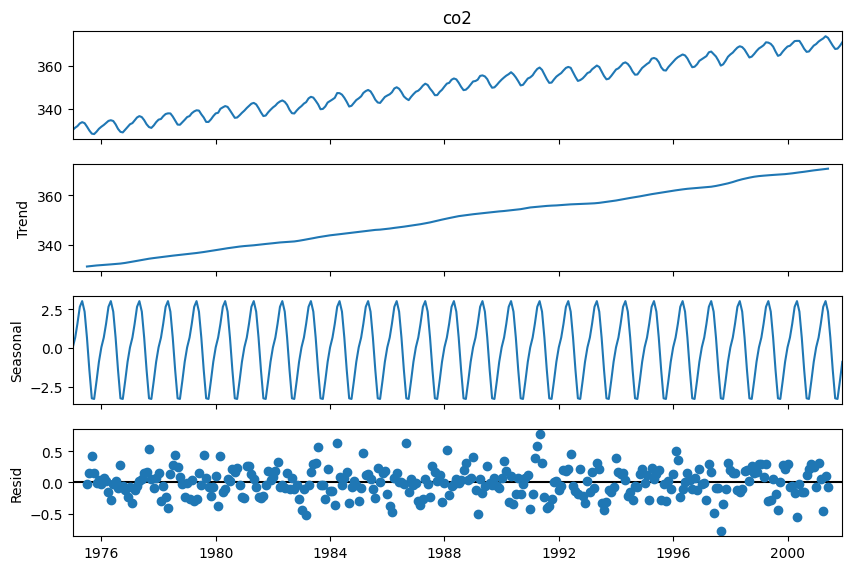

In [2]:
decomp = seasonal_decompose(y, model="additive", period=12)
decomp.plot()
plt.gcf().set_size_inches(9, 6)
plt.show()

In [3]:
def adf_report(series, name):
    stat, pvalue = adfuller(series.dropna())[:2]
    print(f"ADF on {name:34s} p-value = {pvalue:.4f}  ({'non-stationary' if pvalue > 0.05 else 'stationary'})")

adf_report(y, "raw series")
adf_report(y.diff(), "first difference")
adf_report(y.diff().diff(12), "first + seasonal difference")

ADF on raw series                         p-value = 0.9628  (non-stationary)
ADF on first difference                   p-value = 0.0007  (stationary)
ADF on first + seasonal difference        p-value = 0.0000  (stationary)


## Part 2 - ACF / PACF on the differenced series

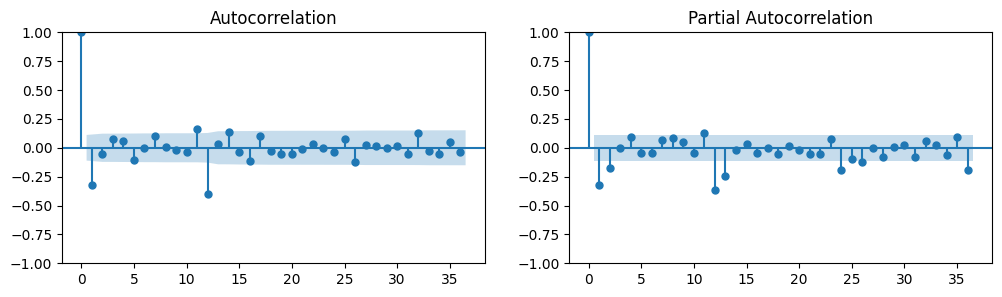

In [4]:
w = y.diff().diff(12).dropna()  # d=1, D=1, s=12
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
plot_acf(w, lags=36, ax=axes[0])
plot_pacf(w, lags=36, ax=axes[1], method="ywm")
plt.show()

The significant spike at lag 12 in the ACF (and its decay pattern) suggests a seasonal
MA(1) term; the small early lags suggest low non-seasonal orders. A standard candidate
for this series is the "airline model" SARIMA(0,1,1)(0,1,1)12 - we compare a small grid by AIC.

In [5]:
train, test = y[:-36], y[-36:]  # hold out the last 3 years

candidates = [
    ((0, 1, 1), (0, 1, 1, 12)),
    ((1, 1, 0), (0, 1, 1, 12)),
    ((1, 1, 1), (0, 1, 1, 12)),
    ((0, 1, 1), (1, 1, 0, 12)),
    ((2, 1, 0), (0, 1, 1, 12)),
]
results = {}
for order, seasonal in candidates:
    model = SARIMAX(train, order=order, seasonal_order=seasonal).fit(disp=False)
    results[(order, seasonal)] = model
    print(f"SARIMA{order}x{seasonal}: AIC = {model.aic:.1f}")

best_key = min(results, key=lambda k: results[k].aic)
best = results[best_key]
print("\nselected:", best_key)

SARIMA(0, 1, 1)x(0, 1, 1, 12): AIC = 106.3


SARIMA(1, 1, 0)x(0, 1, 1, 12): AIC = 112.8


SARIMA(1, 1, 1)x(0, 1, 1, 12): AIC = 108.3
SARIMA(0, 1, 1)x(1, 1, 0, 12): AIC = 168.8


SARIMA(2, 1, 0)x(0, 1, 1, 12): AIC = 108.4

selected: ((0, 1, 1), (0, 1, 1, 12))


## Part 3 - Residual diagnostics

A good model leaves *white noise* behind: flat residual ACF, roughly normal residuals,
Ljung-Box p-values above 0.05. Structured residuals = missed signal.

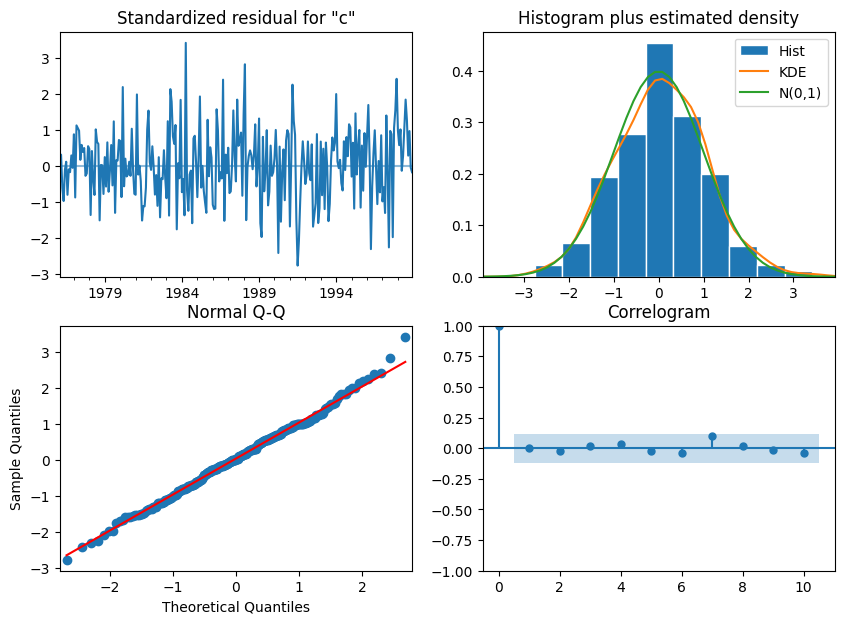

     lb_stat  lb_pvalue
12   6.09158   0.911395
24  16.29169   0.877261

In [6]:
best.plot_diagnostics(figsize=(10, 7))
plt.show()

lb = sm.stats.acorr_ljungbox(best.resid[13:], lags=[12, 24], return_df=True)
print(lb)

## Part 4 - Forecast with uncertainty, and backtest

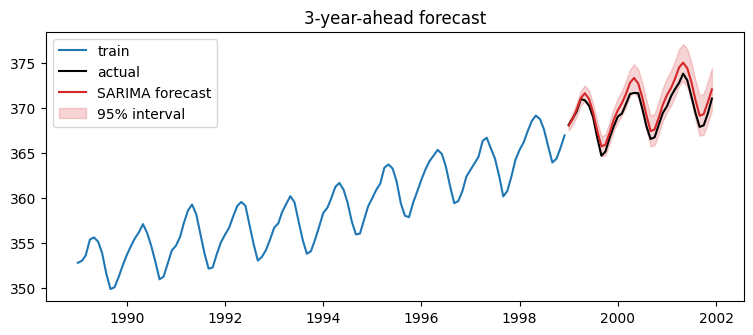

In [7]:
fc = best.get_forecast(steps=36)
ci = fc.conf_int()

plt.figure(figsize=(9, 3.5))
plt.plot(train[-120:], label="train")
plt.plot(test, label="actual", color="k")
plt.plot(fc.predicted_mean, label="SARIMA forecast", color="C3")
plt.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="C3", alpha=0.2, label="95% interval")
plt.legend(); plt.title("3-year-ahead forecast")
plt.show()

In [8]:
# baselines every forecast must beat
naive = pd.Series(train.iloc[-1], index=test.index)                  # last value
seasonal_naive = pd.Series(train.iloc[-12:].values.tolist() * 3, index=test.index)  # same month last year

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

print(f"RMSE  naive:          {rmse(test, naive):.3f}")
print(f"RMSE  seasonal naive: {rmse(test, seasonal_naive):.3f}")
print(f"RMSE  SARIMA:         {rmse(test, fc.predicted_mean):.3f}")

RMSE  naive:          3.336
RMSE  seasonal naive: 3.109
RMSE  SARIMA:         1.047


### Rolling-origin backtest

One split is an anecdote. Refit on expanding windows and forecast 12 months from several
origins - this is the honest way to evaluate any time-series model.

In [9]:
horizons = []
for origin in range(len(y) - 72, len(y) - 12, 12):
    tr = y.iloc[:origin]
    m = SARIMAX(tr, order=best_key[0], seasonal_order=best_key[1]).fit(disp=False)
    pred = m.forecast(12)
    horizons.append(rmse(y.iloc[origin:origin + 12], pred))
print(f"12-month RMSE across {len(horizons)} origins: {np.mean(horizons):.3f} +- {np.std(horizons):.3f}")

12-month RMSE across 5 origins: 0.570 +- 0.273


### TODO exercises

1. Refit the model *without* the seasonal part (`seasonal_order=(0,0,0,0)`) and look at the
   residual ACF - where does the missed structure show up?
2. Add Holt-Winters (`statsmodels.tsa.holtwinters.ExponentialSmoothing`, additive trend +
   seasonality) to the baseline table. Does it beat SARIMA here?
3. Shuffle-split validation: deliberately evaluate with a *random* train/test split of rows
   and watch the "accuracy" become absurdly optimistic. Explain the leakage.
4. Widen the forecast horizon to 10 years and look at the interval width - why do the
   intervals keep growing?